In [92]:
%reset -f

In [93]:
import pypsa
import pandas as pd
import os
import matplotlib.pyplot as plt

In [94]:
import src.analysis as analysis
import src.filter_network as filter_network
import src.plotting as plotting
import src.utils as utils

In [95]:
data_path = os.path.join(os.getcwd(), 'data')

In [96]:
#Importing network data from excel files; consider moving to csv's

buses_df = pd.read_excel(os.path.join(data_path, 'buses.xlsx'), index_col = 0)
buses_df = buses_df.drop(['MV_bus_2'] ) #dropping the second MV bus, will add back when dealing with switching behaviour

gens_df = pd.read_excel(os.path.join(data_path, 'gens.xlsx'), index_col = 0)
gens_pu_df = pd.read_excel(os.path.join(data_path, 'gen_profiles_pu.xlsx'), index_col = 0)

links_df = pd.read_excel(os.path.join(data_path, 'links.xlsx'), index_col = 0)

loads_df = pd.read_excel(os.path.join(data_path, 'loads.xlsx'), index_col = 0)
loads_pu_df = pd.read_excel(os.path.join(data_path, 'load_profiles_pu.xlsx'), index_col = 0)


In [97]:
# Adding thermal buses at same locations as electrical buses, to represent thermal energy flows.
thermal_buses_df = buses_df.copy(deep = True)
thermal_buses_df.index = thermal_buses_df.index + '_thermal'
thermal_buses_df['carrier'] = 'thermal'
thermal_buses_df = thermal_buses_df.drop(columns = ['v_nom'])
thermal_buses_df = thermal_buses_df.drop(index = ['Extern_grid_thermal'])
thermal_buses_df

,x,y,carrier
name,,,
Industry_1_thermal,7.939685,48.466652,thermal
Kritis_1_thermal,7.940721,48.464698,thermal
Residential_1_thermal,7.941092,48.466760,thermal
MV_bus_1_thermal,7.937179,48.466180,thermal


Pypsa resolves carriers by carrier of buses, carriers on gens and loads, are just for grouping and statistics, and don't mean much.  
What matters is what is connected to which bus!!

In [98]:
# adding gas buses at same locations as electrical buses, to represent gas energy flows.
gas_buses_df = buses_df.copy(deep = True)
 
gas_buses_df.index = gas_buses_df.index + '_gas'
gas_buses_df.index = gas_buses_df.index.str.replace('Extern_grid_gas', 'Gas_substation')
gas_buses_df.loc['Gas_substation', 'x'] = gas_buses_df.loc['Gas_substation', 'x'] - 0.01 #jsut offsetting it a bit, might be usefule later while visualizing
gas_buses_df['carrier'] = 'gas'
gas_buses_df = gas_buses_df.drop(columns = ['v_nom'])
gas_buses_df

,x,y,carrier
name,,,
Industry_1_gas,7.939685,48.466652,gas
Kritis_1_gas,7.940721,48.464698,gas
Residential_1_gas,7.941092,48.466760,gas
Gas_substation,7.931827,48.467811,gas
MV_bus_1_gas,7.937179,48.466180,gas


In [99]:
def clean_index(snaps, df):
    """
    Function to clean the index of a dataframe to match the snapshots of the network.
    This is useful when the index of the dataframe does not match the snapshots of the network.
    Will sort out small float point erros, and also point if big errors
    """
    df.index = pd.to_datetime(df.index)
    missing_idxs = set(snaps) - set(df.index)
    if len(missing_idxs) > 0:
        print(f"{set(snaps) - set(df.index)} missing from dataframe index.")
    if len(df.index) != len(snaps):
        raise ValueError(f"Length of dataframe index ({len(df.index)}) does not match length of snapshots ({len(snaps)}).")
    else:
        print(f"Length of both match, overwriting dataframe index with snapshots.")
        df.index = snaps
    return df

In [100]:
n = pypsa.Network()

# n.set_snapshots(pd.date_range('2026-01-01 10:00:00', '2026-01-01 12:00:00', freq = 'h'))
n.set_snapshots(pd.date_range('2026-01-01 00:00:00', '2026-12-31 23:00:00', freq = 'h'))
## verify index of load/gen profile input datasets
loads_pu_df = clean_index(n.snapshots, loads_pu_df)
gens_pu_df = clean_index(n.snapshots, gens_pu_df)

# adding buses
n.add('Bus', buses_df.index, v_nom = buses_df['v_nom'], x = buses_df['x'], y = buses_df['y'], )
n.add('Bus', thermal_buses_df.index, x = thermal_buses_df['x'], y = thermal_buses_df['y'], carrier = thermal_buses_df['carrier'])
n.add('Bus', gas_buses_df.index, x = gas_buses_df['x'], y = gas_buses_df['y'], carrier = gas_buses_df['carrier'])

#adding gens

n.add('Generator', gens_df.index, bus = gens_df['bus'], p_nom = gens_df['p_nom'], marginal_cost = gens_df['marginal_cost'], control = gens_df['control'], carrier = gens_df['carrier'])
n.generators_t.p_max_pu = gens_pu_df

#adding loads
loads_pset = loads_pu_df.multiply(loads_df['p_max'], axis = 1)
n.add('Load', loads_df.index, bus = loads_df['bus'], p_set = loads_pset)

#adding links
# links best represent abstracted DC flows, we don't want AC power dynamics, voltage angles and so on
n.add('Link', links_df.index, bus0 = links_df['bus0'], bus1 = links_df['bus1'], bus2 = links_df['bus2'], carrier = links_df['carrier'], p_nom = links_df['p_nom'], efficiency = links_df['efficiency'], efficiency2 = links_df['efficiency2'], p_min_pu = links_df['p_min_pu'])
n.links_t.efficiency['Residential_HeatPump'] = gens_pu_df['HP_COP'] #efficiency of heat pump is time dependent

# adding slack gens in each bus to represent load shedding
for bus in n.buses.index:
    n.add('Generator', f'Slack_{bus}', bus = bus, p_nom = 100, marginal_cost = 10000, control = 'Slack', carrier = 'Load_shed') #carrier helps to group later

# adding a sink to represent export of excess energy to grid
n.add('Store', 'Export_sink', bus = 'Extern_grid', e_nom = 10000, e_initial = 0, marginal_cost = 0, carrier = 'Export')


{Timestamp('2026-12-31 23:00:00')} missing from dataframe index.
Length of both match, overwriting dataframe index with snapshots.
Length of both match, overwriting dataframe index with snapshots.


**CHP, and grid exports**  
The store gives surplus electricity somewhere to flow.  
The surplus could also be re-distributed within the grid, would depend on the costs set.  
Exact flow tracing is not essential for this study, that trouble could be neglected.  
Exports could still be considered, and appropriate export and import tariffs could be used.  


In [101]:
def register_carriers(n):
    carriers = pd.unique(pd.concat([
        n.buses["carrier"],
        n.generators["carrier"],
        n.links["carrier"],
        n.loads["carrier"],
        n.stores["carrier"]
    ]).dropna())

    colors = {
    "AC": "tab:blue",
    "grid": "tab:cyan",
    "solar": "gold",
    "gas": "#7e1408",
    "heat": "orange",
    "GasBoiler": "tab:red",
    "Load_shed": "black",
    "CHP": "#f57c0a",
    "HP" : "#e8ff00",
    "Export" : "#ff00f6"
}
    for carrier in carriers:
        if carrier not in n.carriers.index:
            n.add("Carrier", carrier)
        n.carriers.loc[carrier, "color"] = colors.get(carrier, "tab:gray")  # Assign color or default to gray       

register_carriers(n)

In [102]:
n.sanitize()

INFO:pypsa.consistency:Sanitizing network...
INFO:pypsa.consistency:Network sanitization complete.


In [103]:
n.optimize(), n.objective

C:\Users\student\AppData\Local\Temp\ipykernel_13548\1191575196.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(), n.objective
Index(['HP_COP'], dtype='str')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 4/4 [00:00<00:00, 39.12it/s]
INFO:linopy.io: Writing time: 1.73s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 254040 primals, 621960 duals
Objective: 2.83e+05
Solver: highs
Runtime: 21.83s
MIP gap: inf
Dual bound: 0.00e+00
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-fix-p

(('ok', 'optimal'), 283053.24408584385)

In [104]:
# verifying heat pump cop working well
hp_thermal = -1 * n.links_t.p1['Residential_HeatPump']

hp_env = n.links_t.p['Residential_HeatPump']
hp_thermal / hp_env


snapshot
2026-01-01 00:00:00    2.5
2026-01-01 01:00:00    2.4
2026-01-01 02:00:00    2.4
2026-01-01 03:00:00    2.3
2026-01-01 04:00:00    2.3
                      ... 
2026-12-31 19:00:00    2.8
2026-12-31 20:00:00    2.7
2026-12-31 21:00:00    2.6
2026-12-31 22:00:00    2.5
2026-12-31 23:00:00    2.5
Freq: h, Name: Residential_HeatPump, Length: 8760, dtype: float64

## Visualization

### Electric

In [105]:
el_buses = n.buses[n.buses.carrier == 'AC'].index
el_gens = n.generators.loc[n.generators['bus'].isin(el_buses)]
el_gens = el_gens.loc[el_gens['carrier'] != 'Load_shed'] #removing slack gens from the list of electrical gens

el_load_shed = n.generators.loc[n.generators['carrier'] == 'Load_shed'] #:)



In [106]:
n.stores.loc['Export_sink', 'carrier']

'Export'

In [107]:
# Determining the energy balance at each bus
bus_sizes, bus_sizes_norm = filter_network.calc_bus_sizes(n)


#normalised bus sizes, to get a sense of the relative contribution of each carrier at each bus


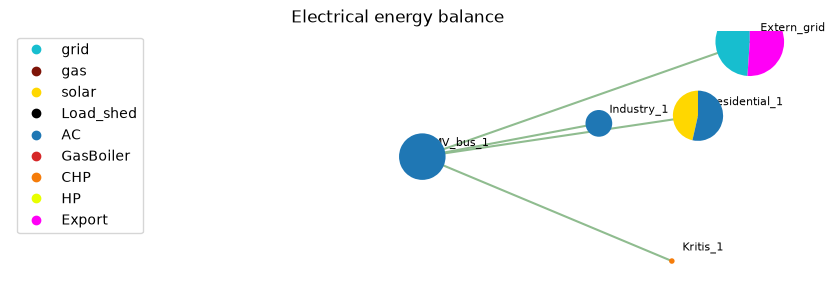

In [108]:
fig, ax = plt.subplots(figsize = (10,8))
plotting.plot_EnBalance(n, 'AC', ax, bus_sizes = bus_sizes, title = 'Electrical energy balance', bus_scale = 1e-10)

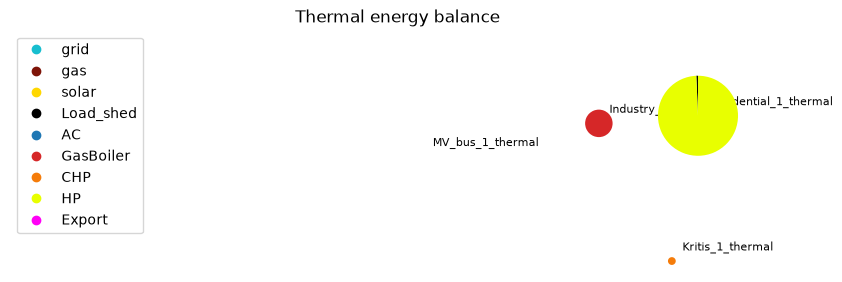

In [109]:
fig, ax = plt.subplots(figsize = (10,8))
plotting.plot_EnBalance(n, 'thermal', ax, bus_sizes = bus_sizes, title = 'Thermal energy balance', bus_scale = 1e-10)

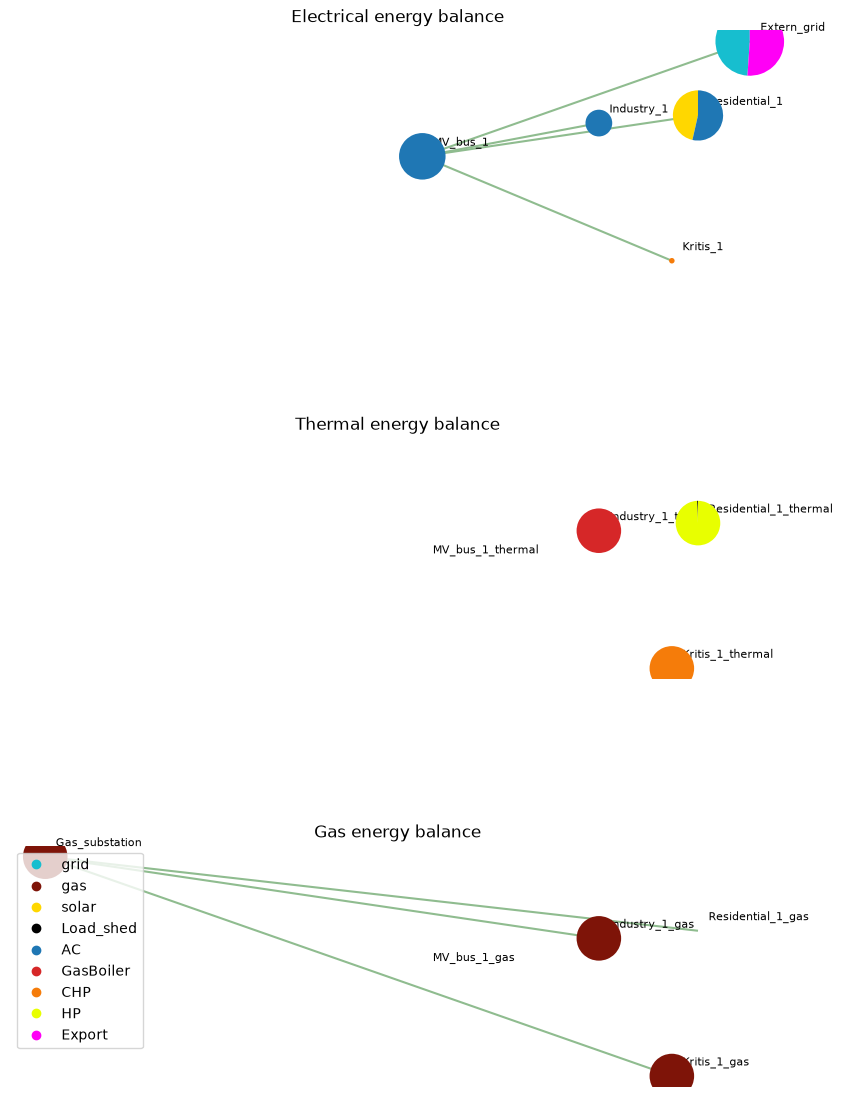

In [110]:
fig, ax = plt.subplots(figsize=(10, 15), nrows = 3)
plotting.plot_EnBalance(n, 'AC', ax[0], bus_sizes = bus_sizes, title = 'Electrical energy balance', bus_scale = 1e-10)
plotting.plot_EnBalance(n, 'thermal', ax[1], bus_sizes = bus_sizes_norm, bus_scale = 1e-7, title = 'Thermal energy balance')
plotting.plot_EnBalance(n, 'gas', ax[2], bus_sizes = bus_sizes_norm, bus_scale = 1e-7, title = 'Gas energy balance')

In [111]:
n.links_t.p['Industry_boiler'].iloc[0], n.links_t.p1['Industry_boiler'].iloc[0], n.links_t.p2['Industry_boiler'].iloc[0], n.links_t.p['Industry_boiler'].max()

(np.float64(0.09596666666666664),
 np.float64(-0.08636999999999999),
 np.float64(0.0),
 0.1945666666666666)

In [112]:
n.links.loc['Industry_boiler']['efficiency'] * n.links.loc['Industry_boiler']['p_nom'] 

np.float64(0.45)

In [113]:
(n.loads_t.p_set['industry_thermal'].round(16) + n.links_t.p1['Industry_boiler'].round(16)).sum()

np.float64(0.0)

In [114]:
n.loads_t.p_set['kritis_thermal'] + n.links_t.p1['Kritis_CHP']

snapshot
2026-01-01 00:00:00    0.0
2026-01-01 01:00:00    0.0
2026-01-01 02:00:00    0.0
2026-01-01 03:00:00    0.0
2026-01-01 04:00:00    0.0
                      ... 
2026-12-31 19:00:00    0.0
2026-12-31 20:00:00    0.0
2026-12-31 21:00:00    0.0
2026-12-31 22:00:00    0.0
2026-12-31 23:00:00    0.0
Freq: h, Length: 8760, dtype: float64

In [115]:
n.loads_t.p_set['kritis'] + n.links_t.p2['Kritis_CHP']
# electricity demand beign matched, neglecting required thermal

snapshot
2026-01-01 00:00:00   -0.001345
2026-01-01 01:00:00   -0.000945
2026-01-01 02:00:00   -0.004845
2026-01-01 03:00:00   -0.003545
2026-01-01 04:00:00   -0.002745
                         ...   
2026-12-31 19:00:00   -0.003567
2026-12-31 20:00:00   -0.003567
2026-12-31 21:00:00   -0.004067
2026-12-31 22:00:00   -0.005067
2026-12-31 23:00:00   -0.003684
Freq: h, Length: 8760, dtype: float64

### Component loading

In [116]:
import numpy as np
from adjustText import adjust_text #to print text without overlaps automatically
import matplotlib.cm as cm
import matplotlib.colors as colors

In [117]:
def get_carrier_Xlinks(n, carrier):
    """
    Function to get the X-coupling links connected with buses of given carrier.
    considers if either of the two output buses is connected to a bus of the given carrier
    """
    buses = n.buses[n.buses.carrier == carrier].index
    # Transport links have carriers like AC or gas
    Xlinks = n.links.loc[((n.links.carrier != 'AC') & (n.links.carrier != 'gas')) & ((n.links.bus1.isin(buses)) | (n.links.bus2.isin(buses)))]
    return Xlinks

**Setup instruction**
The carrier of transport links have to be set similar to that of the buses it connections.  
Leaving it empty, would make it default to this.  
Xlinks should have carreirs defined by their techs.  


In [118]:
def get_carrieronly_network(n, carrier):
    '''
    Function that would return entities associated with buses of a given carrier.
    Currently the returns are:
    - Buses: all buses of the given carrier
    - gens: all gens connected to buses of the given carrier
    - loads: all loads connected to buses of the given carrier
    - links: all transport links of the given carrier
    - Xlinks: all sector-coupling links connected to buses of the given carrier
    - Stores: all stores connected to buses of the given carrier
    '''

    cr_buses = n.buses[n.buses.carrier == carrier].index
    trans_links = n.links[n.links.carrier == carrier].index
    gens = n.generators[(n.generators.bus.isin(cr_buses)) & (n.generators.carrier != 'Load_shed')].index
    loads = n.loads[n.loads.bus.isin(cr_buses)].index
    Xlinks = get_carrier_Xlinks(n, carrier).index
    stores = n.stores[n.stores.bus.isin(cr_buses)].index
    slacks = n.generators[(n.generators.carrier == 'Load_shed') & (n.generators.bus.isin(cr_buses))].index

    network_slice = {
        'buses': cr_buses,
        'gens': gens,
        'trans_links': trans_links,
        'loads': loads,
        'xlinks': Xlinks,
        'stores': stores,
        'slacks': slacks
    }

    return network_slice

In [119]:
carrier = 'AC'
n.buses[n.buses.carrier == carrier]

,v_nom,type,x,y,carrier,unit,location,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,control,generator,sub_network
name,,,,,,,,,,,,,
Industry_1,0.4,,7.939685,48.466652,AC,,,1.0,0.0,inf,Slack,Slack_Industry_1,0
Kritis_1,0.4,,7.940721,48.464698,AC,,,1.0,0.0,inf,Slack,Slack_Kritis_1,1
Residential_1,0.4,,7.941092,48.466760,AC,,,1.0,0.0,inf,Slack,Slack_Residential_1,2
Extern_grid,110.0,,7.941827,48.467811,AC,,,1.0,0.0,inf,Slack,Grid,3
MV_bus_1,20.0,,7.937179,48.466180,AC,,,1.0,0.0,inf,Slack,Slack_MV_bus_1,4


In [120]:
def compute_comp_loading(n, carrier='all'):
    '''
    Function to compute the loading of all components of a given carrier, and returns a dataframe.
    Return:
    A dictionary with keys of component types, and values with dataframes of loading for each snapshot.
    example:
    {
        'gens': pd.DataFrame(...),}
    '''

    if carrier == 'all': #untested, but should work
        loading = {}
        loading['gens'] = (n.generators_t.p.abs() / n.generators['p_nom'])
        xlinks = n.links[((n.links.carrier != 'AC') & (n.links.carrier != 'gas') & (n.links.carrier != 'thermal'))].index
        loading['trans_links'] = (n.links_t.p1.abs() / n.links['p_nom']).loc[:,n.links.index.difference(xlinks)]
        #sector-coupling links loading, using p0 instead of p1, p_nom limits p0, hence this is more reasonable
        loading['xlinks'] = (n.links_t.p0.abs() / n.links['p_nom']).loc[:,xlinks]
        
    else:
        cr_network = get_carrieronly_network(n, carrier) #calling this method here makes it more easier for user, if they wish to calculate loading on all components irrespective of carrier
        loading = {}
        loading['gens'] = (n.generators_t.p[cr_network['gens']].abs() / n.generators.loc[cr_network['gens'], 'p_nom'])
        loading['trans_links'] = (n.links_t.p1[cr_network['trans_links']].abs() / n.links.loc[cr_network['trans_links'], 'p_nom'])
        #sector-coupling links loading, using p0 instead of p1, p_nom limits p0, hence this is more reasonable
        loading['xlinks'] = (n.links_t.p0[cr_network['xlinks']].abs() / n.links.loc[cr_network['xlinks'], 'p_nom'])

        
        return loading

In [121]:
def prep_colour_scheme(quantity, thresholds = {'Default' : 1}, get_cmap = False):
    '''
    Function to prepare a colour scheme according to the provided loading and specified thresholds.
    Threshold being used to consider appropriate loading for heat pumps; 
    could also be used to set 0.75 or something as the threshold for transport lines (N-1 criteria)
    '''

    cmap = plt.get_cmap('bwr')
    norm = colors.Normalize(vmin=0, vmax=thresholds.get('Default', 1))
    

    col_scheme = {
        comp: {
            entity: cmap(norm(quantity[comp][entity])) for entity in quantity[comp].keys()
        }for comp in quantity.keys()
    }
    col_scheme['bus'] = 'orange'  # Keeping bus color constant
    # now the seperate threshold for heat pump
    if get_cmap is False:
        return col_scheme
    else:
        return col_scheme, cmap, norm

In [122]:
def plot_network(ax, n, carrier, show_slacks = False, col_scheme = None, title = None):
    """
    Plots the network of the specified carrier with the specified colour scheme.
    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes on which the network is drawn.
    n : pypsa.Network
        PyPSA network containing buses, generators and links.
    carrier : str
        Carrier whose network topology should be visualized (e.g. "AC", "heat").
    show_slacks : bool, default=False
        If True, include slack generators in the plot.
    col_scheme : dict, optional
        Dictionary specifying colours for generators, links, buses and sector-coupling links.
    title : str, optional
        Title of the plot.

    """
    if col_scheme is None: #better practice to set mutable defaults inside function, else changes made here, would pass to other calls
        col_scheme = {'gens' : {}, 'xlinks' : {}, 'bus' : 'orange', 'trans_links' : {}}
    # Slicing the network for the given carrier, and unpacking
    cr_network = get_carrieronly_network(n, carrier)
    gens = cr_network['gens']
    Xlinks = cr_network['xlinks']
    transport_links = cr_network['trans_links']
    buses = cr_network['buses']

    #Aggregating generators and X-coupling links per bus, to plot them radially around the bus
    if show_slacks is False:
        gens_per_bus = n.generators.loc[gens].groupby('bus').groups
    else:
        gens_per_bus = n.generators.groupby('bus').groups
    out_buses = n.links.loc[Xlinks][['bus1', 'bus2']].stack().reset_index(level = 1, drop = True).rename('out_buses')
    out_buses = out_buses[out_buses != ''] #removing the empty buses
    Xlinks_per_bus = out_buses.groupby(out_buses).groups #Duplication is not an issue, since we are iterating through buses to plot
    
    
    #Plotting buses
    ax.scatter(n.buses.loc[buses].x, n.buses.loc[buses].y, s = 100, color = col_scheme.get('bus'), label = 'Buses', zorder = 3)

    #Plotting transport links or lines
    for link in transport_links:
        link_x0 = n.links.bus0.map(n.buses.x)[link]
        link_y0 = n.links.bus0.map(n.buses.y)[link]
        link_x1 = n.links.bus1.map(n.buses.x)[link]
        link_y1 = n.links.bus1.map(n.buses.y)[link]
        ax.plot([link_x0, link_x1], [link_y0, link_y1], color = col_scheme.get('trans_links').get(link, 'grey'), alpha = 1)
    
    texts = [] #all text collexted here, and managed by adjust_text to avoid overlaps
    # offset = 80e-6
    offset = 0
    #Plotting generators and sector-coupling gens, and distributing them radially around the bus
    radius = 0.0002
    angles_gens = {}
    angles_xlinks = {}
    ##Plotting gens and Xlilnks bus-wise
    for bus in buses:
        bus_gens = gens_per_bus.get(bus)
        bus_Xlinks = Xlinks_per_bus.get(bus)
        
        bus_x = n.buses.loc[bus].x
        bus_y = n.buses.loc[bus].y

        #Annotation for bus
        texts.append(ax.text(bus_x + offset, bus_y + offset, bus, fontsize = 8))

        ## What happens if there are no gens or Xlinks connected to the bus? 
        if bus_gens is not None and len(bus_gens) > 0:
            angles_gens = np.linspace(0, np.pi, len(bus_gens), endpoint=False)
            for gen, angle in zip(bus_gens, angles_gens):
                gen_x = bus_x + radius * np.cos(angle)
                gen_y = bus_y + radius * np.sin(angle)
                ax.scatter(gen_x, gen_y, s = 50, color = col_scheme.get('gens').get(gen, 'green'), label = 'Generators')
                ax.plot([bus_x, gen_x], [bus_y, gen_y], color = 'grey', alpha = 0.5)
                texts.append(ax.text(gen_x + offset, gen_y + offset, gen, fontsize = 8))
        
        if bus_Xlinks is not None and len(bus_Xlinks) > 0:
            angles_xlinks = np.linspace(np.pi, 2*np.pi, len(bus_Xlinks), endpoint=False)
            for Xlink, angle in zip(bus_Xlinks, angles_xlinks):
                Xlink_x = bus_x + radius * np.cos(angle)
                Xlink_y = bus_y + radius * np.sin(angle)
                ax.scatter(Xlink_x, Xlink_y, s = 50, color = col_scheme.get('xlinks').get(Xlink, 'teal'), label = 'X-coupling links')
                ax.plot([bus_x, Xlink_x], [bus_y, Xlink_y], color = 'grey', alpha = 0.5)
                texts.append(ax.text(Xlink_x + offset, Xlink_y + offset, Xlink, fontsize = 8))

    adjust_text(texts, ax = ax, arrowprops=dict(arrowstyle='->', color='red'))

    ax.set_xticks([])
    ax.set_yticks([])
    
    #removing duplicate legends
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())

    if title is not None:
        ax.set_title(title)

    



In [123]:
def plot_90th_percentile_loading(n, carrier, ax, comp_loading = None, title = None):
    """
    Funciton to plot the 90th percentile loading of all components of specified carrier.
    Parameters:
    ----------
    n : pypsa.Network
    carrier : str, Carrier whose network topology should be visualized (e.g. "AC", "heat").
    ax : matplotlib.axes.Axes
    comp_loading: dict, optional, default = None
    Dictionary containing dataframes of loading for each component type. If None, will be computed, 
    provides user flexibility to slice the component loading dataframes.
    
    """
    if comp_loading is None:
        comp_loading = compute_comp_loading(n, carrier)

    comp_loading_90th = {
        comp: {
            entity: comp_loading[comp][entity].quantile(0.9) for entity in comp_loading[comp].columns
        }for comp in comp_loading.keys()
    }

    col_scheme, cmap, norm = prep_colour_scheme(comp_loading_90th, get_cmap = True)

    plot_network(ax, n, carrier, col_scheme = col_scheme, title = title)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])   # required by matplotlib

    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("90th percentile loading")


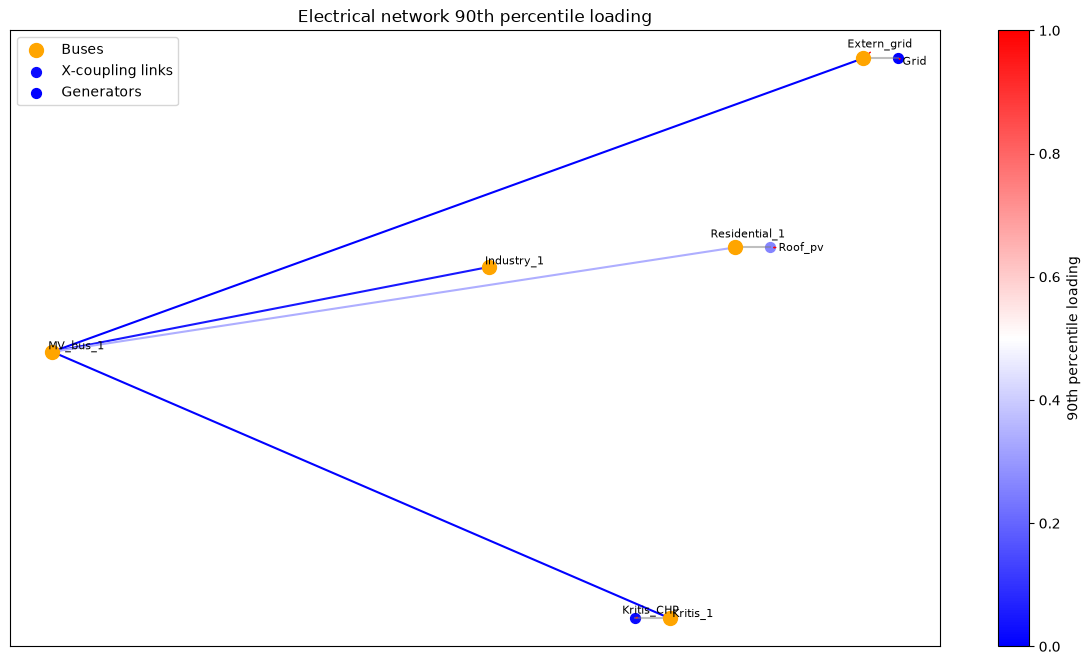

In [124]:
fig, ax = plt.subplots(figsize = (15,8))
loading = compute_comp_loading(n, 'AC')
# loading = {
#     comp: df.loc[:'06-2026', :] for comp, df in loading.items()
# }
plot_90th_percentile_loading(n, 'AC', ax, loading, title = 'Electrical network 90th percentile loading')
plt.show()

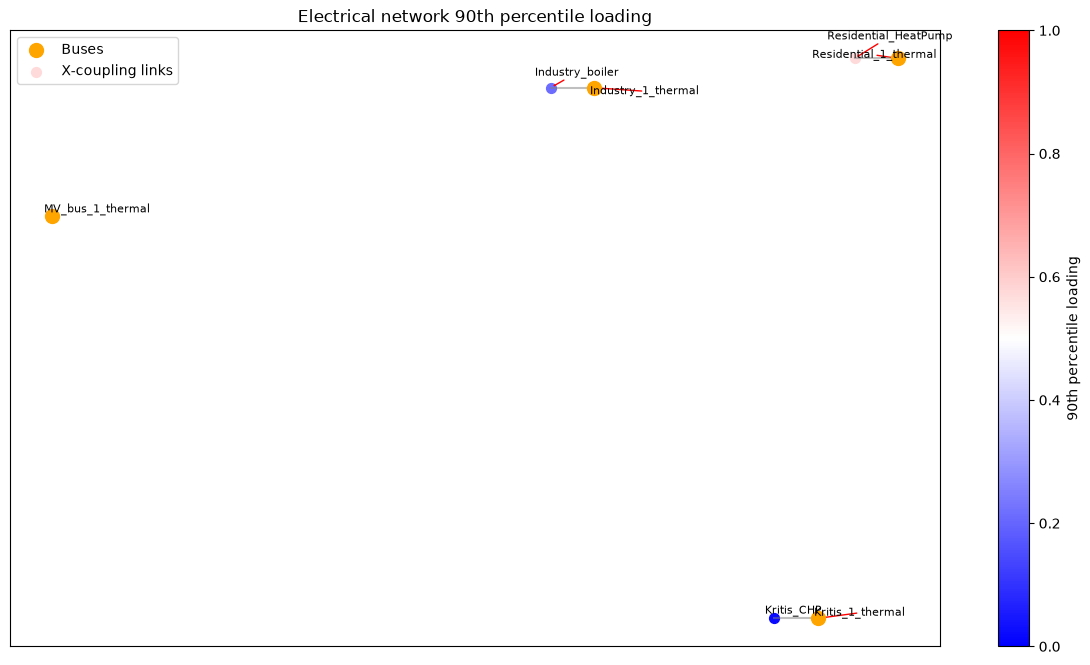

In [125]:
fig, ax = plt.subplots(figsize = (15,8))
loading = compute_comp_loading(n, 'AC')
# loading = {
#     comp: df.loc[:'06-2026', :] for comp, df in loading.items()
# }
plot_90th_percentile_loading(n, 'thermal', ax, title = 'Electrical network 90th percentile loading')
plt.show()

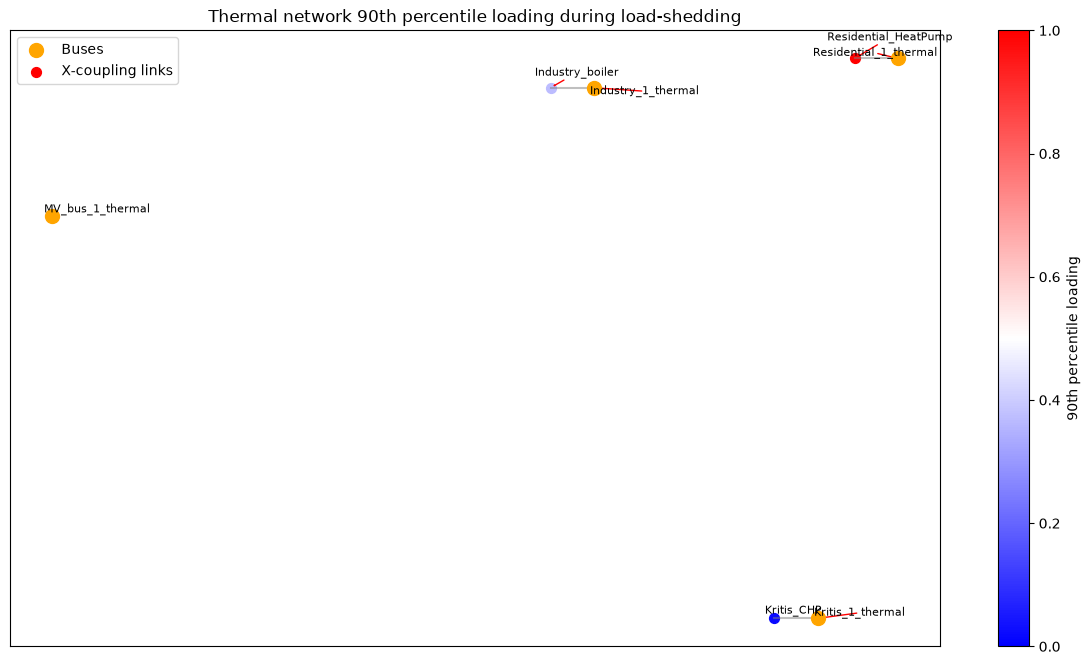

In [126]:
#Plotting only 90th percentile of load shedding snaps

fig, ax = plt.subplots(figsize = (15,8))
loading = compute_comp_loading(n, 'thermal')

slack_gens = n.generators_t.p[get_carrieronly_network(n, 'thermal')['slacks']]
mask = (slack_gens > 0).any(axis = 1)
load_shedding_snaps = n.snapshots[mask]
loading = {
    comp: df.loc[load_shedding_snaps, :] for comp, df in loading.items()
}
plot_90th_percentile_loading(n, 'thermal', ax, loading, title = 'Thermal network 90th percentile loading during load-shedding')
plt.show()

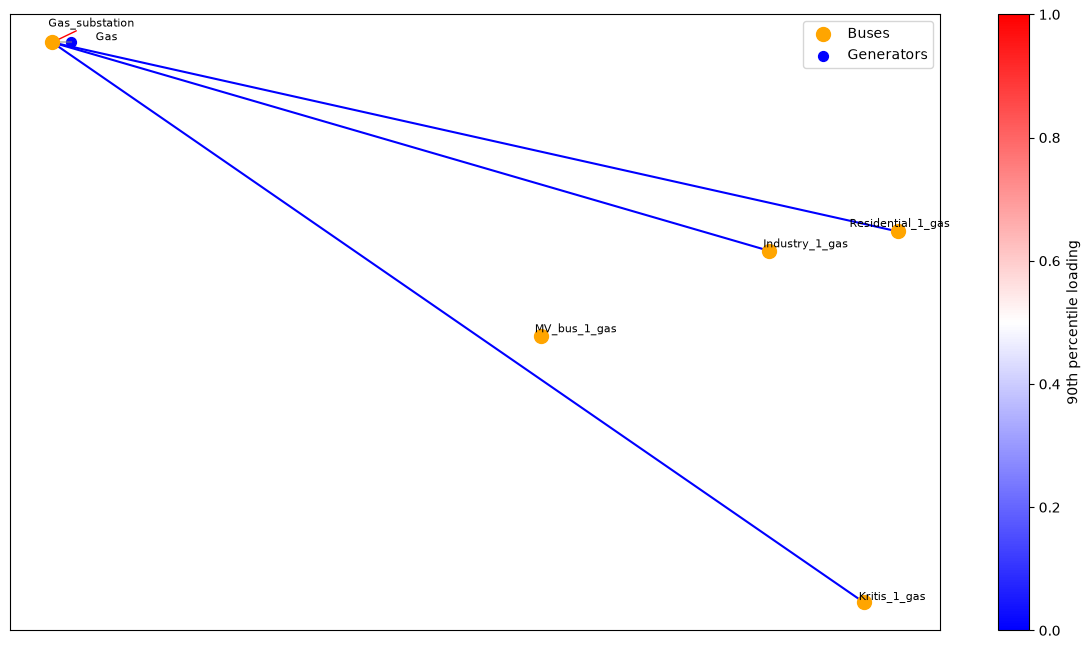

In [127]:
fig, ax = plt.subplots(figsize = (15,8))
plot_90th_percentile_loading(n, 'gas', ax)
plt.show()

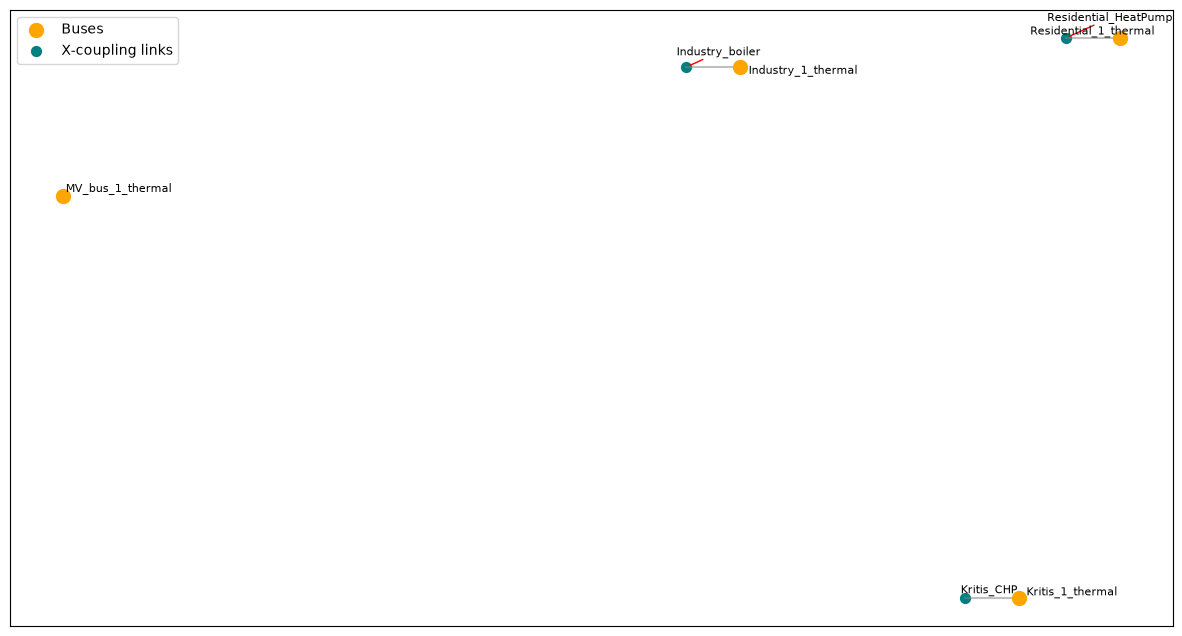

In [128]:
fig, ax = plt.subplots(figsize = (15,8))

plot_network(ax, n, 'thermal', show_slacks=False)

In [129]:
n.links[n.links['carrier'] == 'HP']

,bus0,bus1,bus2,type,carrier,efficiency,efficiency2,active,build_year,lifetime,...,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down,delay,delay2,cyclic_delay,cyclic_delay2,p_nom_opt
name,,,,,,,,,,,,,,,,,,,,,
Residential_HeatPump,Residential_1,Residential_1_thermal,,,HP,1.0,1.0,True,0,inf,...,0,NaN,NaN,NaN,NaN,0,0,True,True,0.5


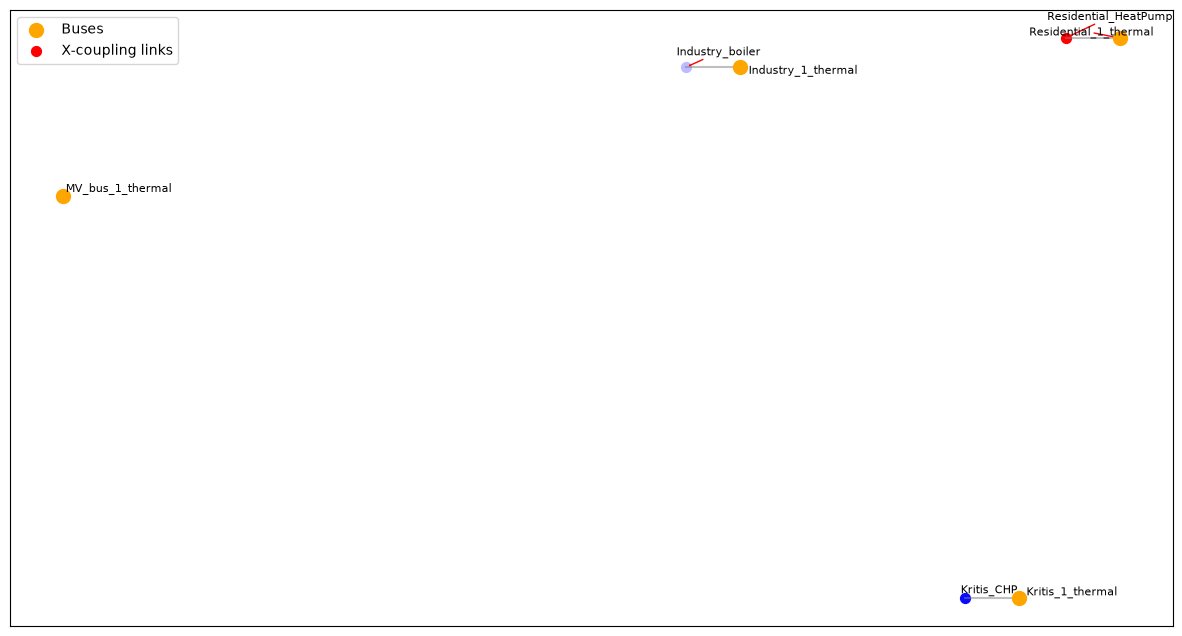

In [130]:
#computing component loading

threshold = 1
carrier = 'thermal'

cr_network = get_carrieronly_network(n, carrier)

#filtering snapshots where load shedding is happening, anywhere

slack_gens = n.generators_t.p[cr_network['slacks']]
mask = (slack_gens > 0).any(axis=1)
load_shedding_snaps = n.snapshots[mask]

loading = compute_comp_loading(n, carrier) 

#preparing colour scheme based on thresholds
## 90th percentile loading during load shedding snaps

# shedding_loading_90th = {comp: {entity: loading[comp][entity].loc[load_shedding_snaps].quantile(0.9)} for comp in loading.keys() for entity in loading[comp].keys()}
shedding_loading_90th = {
    comp: {
        entity: loading[comp][entity].loc[load_shedding_snaps].quantile(0.9)
        for entity in loading[comp].columns}
    for comp in loading.keys()}
# or if a particular index
index = '2026-01-03 06:00:00'
idx_loading = {
    comp: {
        entity: loading[comp][entity].loc[index]
        for entity in loading[comp].columns}
    for comp in loading.keys()
    }

fig, ax = plt.subplots(figsize = (15,8))
plot_network(ax, n, carrier, col_scheme = prep_colour_scheme(shedding_loading_90th))



In [131]:
shedding_loading_90th

{'gens': {},
 'trans_links': {},
 'xlinks': {'Industry_boiler': np.float64(0.3681555555555555),
  'Kritis_CHP': np.float64(0.020000000000000004),
  'Residential_HeatPump': np.float64(1.0)}}

In [132]:
loading.keys()

dict_keys(['gens', 'trans_links', 'xlinks'])

In [133]:
for comp in loading.keys():
    print(f"Component: {comp}")
    for entity in loading[comp].columns:
        print(f"  Entity: {entity}, Loading: {loading[comp][entity].loc[load_shedding_snaps].quantile(0.9)}")

Component: gens
Component: trans_links
Component: xlinks
  Entity: Industry_boiler, Loading: 0.3681555555555555
  Entity: Kritis_CHP, Loading: 0.020000000000000004
  Entity: Residential_HeatPump, Loading: 1.0


In [134]:
shedding_loading_90th

{'gens': {},
 'trans_links': {},
 'xlinks': {'Industry_boiler': np.float64(0.3681555555555555),
  'Kritis_CHP': np.float64(0.020000000000000004),
  'Residential_HeatPump': np.float64(1.0)}}

In [135]:
loading['gens']

name
snapshot
2026-01-01 00:00:00
2026-01-01 01:00:00
2026-01-01 02:00:00
2026-01-01 03:00:00
2026-01-01 04:00:00
...
2026-12-31 19:00:00
2026-12-31 20:00:00
2026-12-31 21:00:00


In [136]:
shedding_loading_90th

{'gens': {},
 'trans_links': {},
 'xlinks': {'Industry_boiler': np.float64(0.3681555555555555),
  'Kritis_CHP': np.float64(0.020000000000000004),
  'Residential_HeatPump': np.float64(1.0)}}

In [137]:
load_shedding_snaps

DatetimeIndex(['2026-01-03 06:00:00', '2026-01-04 06:00:00',
               '2026-01-04 07:00:00', '2026-01-08 06:00:00',
               '2026-01-08 07:00:00', '2026-01-09 06:00:00',
               '2026-01-09 07:00:00', '2026-01-10 05:00:00',
               '2026-01-10 06:00:00', '2026-01-10 07:00:00',
               '2026-01-10 08:00:00', '2026-01-10 09:00:00',
               '2026-01-10 18:00:00', '2026-01-10 19:00:00',
               '2026-01-10 20:00:00', '2026-01-10 21:00:00',
               '2026-01-11 06:00:00', '2026-01-11 07:00:00',
               '2026-01-12 06:00:00', '2026-01-12 07:00:00',
               '2026-01-12 08:00:00', '2026-01-12 18:00:00',
               '2026-01-12 19:00:00', '2026-01-12 20:00:00',
               '2026-01-12 21:00:00', '2026-01-13 05:00:00',
               '2026-01-13 06:00:00', '2026-01-13 07:00:00',
               '2026-01-13 08:00:00', '2026-01-13 09:00:00',
               '2026-01-13 10:00:00', '2026-01-13 11:00:00',
               '2026-01-

In [138]:
shedding_loading_90th

{'gens': {},
 'trans_links': {},
 'xlinks': {'Industry_boiler': np.float64(0.3681555555555555),
  'Kritis_CHP': np.float64(0.020000000000000004),
  'Residential_HeatPump': np.float64(1.0)}}

In [139]:
n.generators_t.p

name,Roof_pv,Grid,Gas,Slack_Industry_1,Slack_Kritis_1,Slack_Residential_1,Slack_Extern_grid,Slack_MV_bus_1,Slack_Industry_1_thermal,Slack_Kritis_1_thermal,Slack_Residential_1_thermal,Slack_MV_bus_1_thermal,Slack_Industry_1_gas,Slack_Kritis_1_gas,Slack_Residential_1_gas,Slack_Gas_substation,Slack_MV_bus_1_gas
snapshot,,,,,,,,,,,,,,,,,
2026-01-01 00:00:00,-0.0,1.775027,0.120505,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
2026-01-01 01:00:00,-0.0,-0.000000,0.115163,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
2026-01-01 02:00:00,-0.0,-0.000000,0.119719,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
2026-01-01 03:00:00,-0.0,-0.000000,0.123850,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
2026-01-01 04:00:00,-0.0,-0.000000,0.116857,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-12-31 19:00:00,-0.0,-0.000000,0.121448,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
2026-12-31 20:00:00,-0.0,-0.000000,0.123288,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
2026-12-31 21:00:00,-0.0,-0.000000,0.118597,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0


In [140]:
cr_network['slacks']

Index(['Slack_Industry_1_thermal', 'Slack_Kritis_1_thermal',
       'Slack_Residential_1_thermal', 'Slack_MV_bus_1_thermal'],
      dtype='object', name='name')

# EOF
rough

In [141]:
n.statistics.energy_balance(bus_carrier = 'AC', groupby = ['bus', 'carrier'])

component  bus            carrier
Generator  Extern_grid    grid       1159.85346
           Residential_1  solar       590.17472
Link       Extern_grid    AC        -1159.85346
           Industry_1     AC          359.99970
           Kritis_1       AC           -4.79393
                          CHP          15.24396
           Residential_1  AC          680.54337
                          HP        -1006.71839
Load       Industry_1     -          -359.99970
           Kritis_1       -           -10.45003
           Residential_1  -          -263.99970
dtype: float64

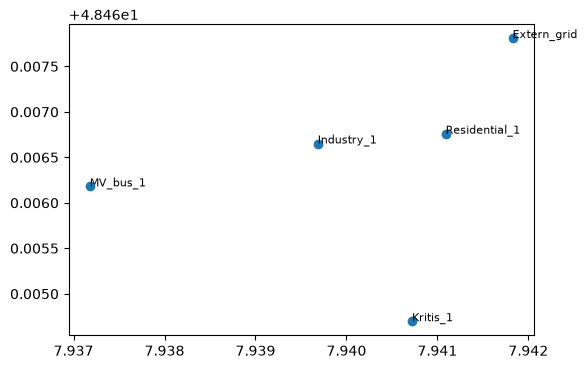

In [142]:
fig, ax = plt.subplots(figsize=(6, 6))

elbusdf = n.buses.loc[el_buses]
ax.scatter(elbusdf.x, elbusdf.y)

for bus in elbusdf.index:
    ax.text(
        elbusdf.loc[bus, "x"],
        elbusdf.loc[bus, "y"],
        bus,
        fontsize=8
    )

ax.set_aspect("equal")
plt.show()

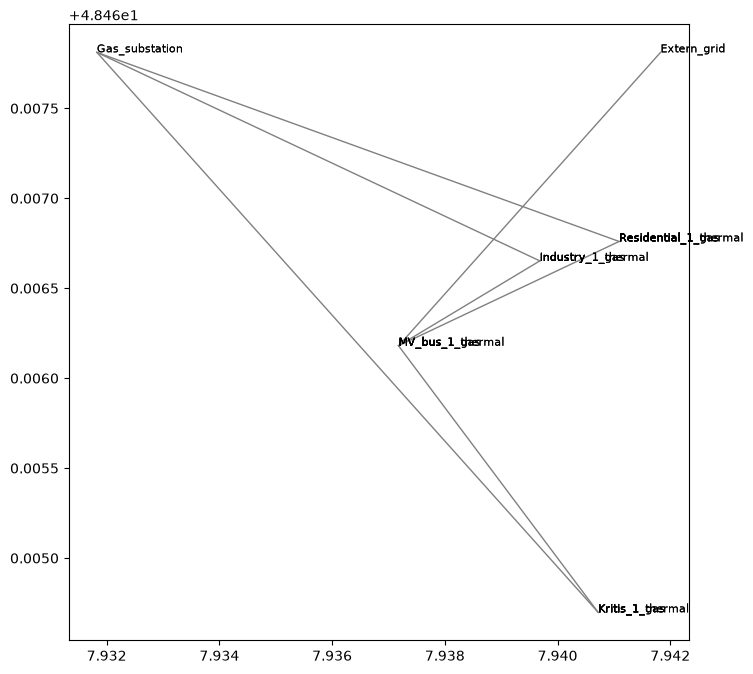

In [143]:
fig, ax = plt.subplots(figsize=(8, 8))

for link in n.links.itertuples():
    x0, y0 = n.buses.loc[link.bus0, ["x", "y"]]
    x1, y1 = n.buses.loc[link.bus1, ["x", "y"]]

    ax.plot(
        [x0, x1],
        [y0, y1],
        color="grey",
        linewidth=1
    )

for bus in n.buses.index:
    ax.text(
        n.buses.loc[bus, "x"],
        n.buses.loc[bus, "y"],
        bus,
        fontsize=8,
        # xytext=(5,5),
        # textcoords="offset points"
    )

for bus in n.buses.index:
    ax.text(
        n.buses.loc[bus, "x"],
        n.buses.loc[bus, "y"],
        bus,
        fontsize=8,
        # xytext=(5,5),
        # textcoords="offset points"
    )

In [144]:
fig, ax = plt.subplots(
    figsize=(12, 8),
    subplot_kw={"projection": ccrs.Mercator()}
)
n.statistics.energy_balance.plot.map( ax = ax, bus_split_circle = False)

NameError: name 'ccrs' is not defined

In [ ]:
n.statistics.energy_balance(
    groupby = ["bus", "carrier"],
    components = ['Generator', 'Load', 'Link']
).groupby(['bus', 'carrier']).sum()
# n.statistics.energy_balance()

In [ ]:

import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(8, 8))

n.plot(
    ax=ax,
    geomap=False,          # <-- key fix: don't require cartopy GeoAxes
    bus_sizes=0.0000000000002,
    bus_colors="steelblue",
    line_widths=0,
    link_widths=2,
    link_colors="firebrick",
    title="Network topology",
)

# add bus name annotations
for name, row in n.buses.iterrows():
    ax.annotate(
        name,
        xy=(row.x, row.y),
        xytext=(5, 5),                # offset in points, so it doesn't sit on top of the marker
        textcoords="offset points",
        fontsize=8,
        ha="left",
    )

plt.tight_layout()
plt.show()

In [ ]:
n.stats.energy_balance().plot()